In [1]:
import sys
from pathlib import Path

def add_src_to_path():
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        src = p / "src"
        if src.is_dir():
            sys.path.insert(0, str(src))
            print(f"✅ Added to sys.path: {src}")
            return src
    raise FileNotFoundError(
        f"Could not find a 'src' directory by walking up from {here}.\n"
        f"Current working dir is: {here}"
    )

SRC_DIR = add_src_to_path()
print("First sys.path entry:", sys.path[0])


✅ Added to sys.path: /home/user/src
First sys.path entry: /home/user/src


# Run the helpers first!!


In [18]:
from collections import OrderedDict
import numpy as np
import torch
from datetime import datetime
from models.LIANet import LIANetLight
import json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_grad_enabled(False)
data_root = "/home/user/data_shared"


run_dir_available = Path("/home/user/results_shared/fourier_learned_2tile_alltimes_USA/2026-01-15_12-33-30")
cfg_path_available = run_dir_available / "used_parameters.json"
ckpt_dir_available = run_dir_available / "model_checkpoints" / "checkpoint_Epoch1601_Iteration3200000.pt"


run_dir_anytime = Path("/home/user/results_shared/fourier_learned_2tile_alltimes_USA_RandomDayTimeSampling/2026-02-10_09-17-01")
cfg_path_anytime = run_dir_anytime / "used_parameters.json"
ckpt_dir_anytime = run_dir_anytime / "model_checkpoints" / "checkpoint_Epoch1601_Iteration3656000.pt"

model_anytime = load_model(cfg_path_anytime, ckpt_dir_anytime, device)
model_available = load_model(cfg_path_available, ckpt_dir_available, device)


[ckpt] missing keys: 0 (showing up to 20): []
[ckpt] unexpected keys: 0 (showing up to 20): []
[ckpt] missing keys: 0 (showing up to 20): []
[ckpt] unexpected keys: 0 (showing up to 20): []


In [81]:
import numpy as np
import torch
from datetime import datetime

# ---- user params ----
col_start = 8000
col_end = 13120  # exclusive
row_start = 0
row_end = 1024   # exclusive
patch_size = 128
batch_size = 64

# choose the time you want the model to generate for
query_dt = datetime(2024, 5, 11, 16, 28, 39)  # (year, month, day, hour, minute, second)

mosaic_available = run_mosaic(
    model_available,
    cfg_path_available,
    col_start=col_start,
    col_end=col_end,
    row_start=row_start,
    row_end=row_end,
    patch_size=patch_size,
    batch_size=batch_size,
    query_dt=query_dt,
)
mosaic_available_np = mosaic_available.detach().cpu().numpy()

mosaic_anytime = run_mosaic(
    model_anytime,
    cfg_path_anytime,
    col_start=col_start,
    col_end=col_end,
    row_start=row_start,
    row_end=row_end,
    patch_size=patch_size,
    batch_size=batch_size,
    query_dt=query_dt,
)
mosaic_anytime_np = mosaic_anytime.detach().cpu().numpy()


In [100]:
import rasterio as rio

from utils import _preprocess_S2
from rasterio.merge import merge


tile_left_before = "/home/user/data_shared/T16TEK/20240406T162829.tif"
tile_left_after = "/home/user/data_shared/T16TEK/20240725T162839.tif"
tile_right_before = "/home/user/data_shared/T16TFK/20240226T163139.tif"
tile_right_after = "/home/user/data_shared/T16TFK/20240630T162901.tif"

with rio.open(tile_left_before) as src1, rio.open(tile_right_before) as src2:
    mosaic_before, out_transform = merge([src1, src2])
mosaic_before = _preprocess_S2(mosaic_before[:, row_start:row_end, col_start:col_end])  


with rio.open(tile_left_after) as src1, rio.open(tile_right_after) as src2:
    mosaic_after, out_transform = merge([src1, src2])
mosaic_after = _preprocess_S2(mosaic_after[:, row_start:row_end, col_start:col_end]) 



t_before = parse_s2_date(tile_left_before)  # same date string for both tiles in "before"
t_after  = parse_s2_date(tile_left_after)

interp = temporal_linear_interp(mosaic_before, t_before, mosaic_after, t_after, query_dt)


# Notes to me

I need a time whose difference is a lot, preferbly one snowy and one green. So, that the bilinear itnerpolation messes up. 
Also, I can show what the image looks like actually, that way not included in the pretraining. 

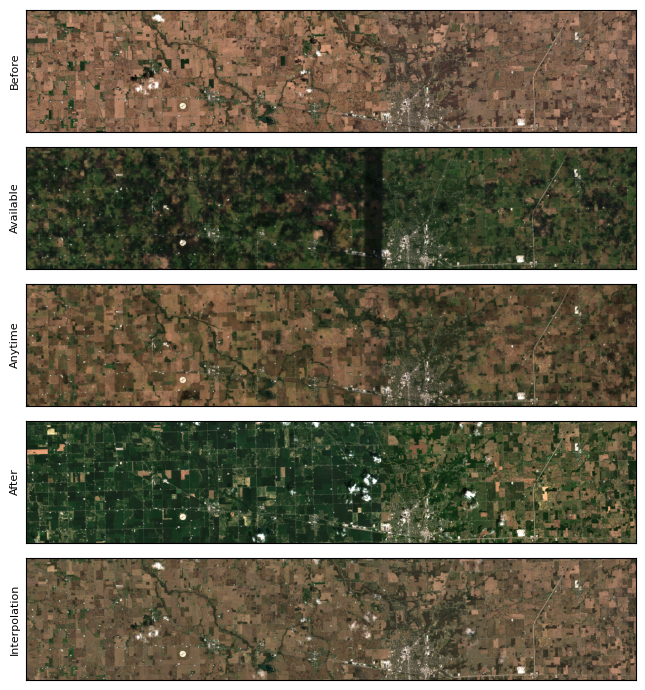

In [110]:
import matplotlib.pyplot as plt
from utils import s2_to_rgb

fig, ax = plt.subplots(5,1, figsize=(10,7))
ax[0].imshow(s2_to_rgb(mosaic_before))
ax[0].set_ylabel(f"Before", fontsize=8)    # : {t_before.strftime('%Y-%m-%d %H:%M:%S')}
ax[1].imshow(s2_to_rgb(mosaic_available_np))
ax[1].set_ylabel(f"Available", fontsize=8) # Model (available times only)
ax[2].imshow(s2_to_rgb(mosaic_anytime_np))
ax[2].set_ylabel(f"Anytime", fontsize=8) # Model (anytime time)
ax[3].imshow(s2_to_rgb(mosaic_after))
ax[3].set_ylabel(f"After", fontsize=8) #: {t_after.strftime('%Y-%m-%d %H:%M:%S')}
ax[4].imshow(s2_to_rgb(interp))
ax[4].set_ylabel(f"Interpolation", fontsize=8) # Linear interp between before/after

for ax_i in ax:
    ax_i.set_xticks([])
    ax_i.set_yticks([])
plt.tight_layout()
# plt.show()
plt.savefig("mosaic_comparison.png", dpi=300)

In [ ]:
# overlap_area = _compute_overlap_x(TILE1_TIF, TILE2_TIF)  # in pixels, e.g. 200
# assert col_start < 10980, f"col_start must be < 10980 to fit within the image bounds, but got {col_start}"
# col_start_left = col_start
# assert col_end > 10980, f"col_end must be > 10980 to go to the right image, but got {col_end}"
# col_start_right = 0
# offset_right_image = col_end - 10980 + overlap_area
# left_img = rio.open(TILE1_TIF) 
# left_img_limited = _preprocess_S2(left_img.read( window=rio.windows.Window(col_start_left, row_start, col_end - col_start, row_end - row_start)))

# right_img = rio.open(TILE2_TIF)
# right_img_limited = _preprocess_S2(right_img.read( window=rio.windows.Window(col_start_right, row_start, offset_right_image, row_end - row_start)))



row_start, row_end = 0, 1024
col_start, col_end = 9000, 11560
overlap_area = _compute_overlap_x(TILE1_TIF, TILE2_TIF)

big, big_transform, crs = stitch_two_tiles_windows(
    TILE1_TIF, TILE2_TIF,
    row_start=row_start, row_end=row_end,
    col_start=col_start, col_end=col_end,
    overlap_area=overlap_area
)

plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.title("Stitched window (left + right)")
plt.axis("off")
plt.show()


# Helpers

In [99]:

def load_model(cfg_path, ckpt_dir, device):

    with open(cfg_path, "r") as f:
        cfg = json.load(f)
    model_kwargs = cfg.get("model", None)

    model = LIANetLight(
        timestamp_dim=model_kwargs["timestamp_dim"], 
        time_mode="fourier_learned", 
        num_time_frequencies=model_kwargs["num_time_frequencies"], 
        time_input_dim=model_kwargs["time_input_dim"], 
        time_mlp_hidden=model_kwargs["time_mlp_hidden"], 
        levels= model_kwargs["levels"], 
        n_min=model_kwargs["n_min"], 
        growth=model_kwargs["growth"], 
        table_size=model_kwargs["table_size"],
        feat_dim=model_kwargs["feat_dim"], 
        complete_tile_size=model_kwargs["complete_tile_size"], # Sentinel-2 max tile size 
        resunet_backbone_size=model_kwargs["resunet_backbone_size"], 
        bilinear=model_kwargs["bilinear"], 
        out_channels=cfg["num_channels"], 
        preproj_channels=model_kwargs["preproj_channels"], 
        ).to(device)
    model.eval()

    ckpt = torch.load(str(ckpt_dir), map_location=device)
    state = ckpt["model_state_dict"]

    if any(k.startswith("module.") for k in state.keys()):
            state = {k.replace("module.", "", 1): v for k, v in state.items()}

    missing, unexpected = model.load_state_dict(state, strict=False)
    print(f"[ckpt] missing keys: {len(missing)} (showing up to 20): {missing[:20]}")
    print(f"[ckpt] unexpected keys: {len(unexpected)} (showing up to 20): {unexpected[:20]}")

    return model


def _time_to_tensor(dt, batch_len, device, time_mode):
    t0 = datetime(2015, 1, 1)
    delta_days = (dt - t0).total_seconds() / 86400.0

    if time_mode in ("sinusoidal", "fourier_learned"):
        return torch.full((batch_len,), float(delta_days), device=device, dtype=torch.float32)
    

def run_mosaic(model, cfg_path, col_start, col_end, row_start, row_end, patch_size=128, batch_size=batch_size, query_dt=None):
    width = col_end - col_start
    height = row_end - row_start
    if width <= 0 or height <= 0:
        raise ValueError("Invalid span: end must be > start.")
    if width % patch_size != 0 or height % patch_size != 0:
        raise ValueError("Width/height must be divisible by patch_size.")
    with open(cfg_path, "r") as f:
        cfg = json.load(f)
    out_channels = cfg["num_channels"]
    mosaic = torch.empty((out_channels, height, width), device=device)

    coords = []
    for y in range(row_start, row_end, patch_size):
        for x in range(col_start, col_end, patch_size):
            coords.append((x, y))

    with torch.no_grad():
        for i in range(0, len(coords), batch_size):
            batch = coords[i:i + batch_size]
            xs = torch.tensor([c[0] for c in batch], device=device, dtype=torch.float32)
            ys = torch.tensor([c[1] for c in batch], device=device, dtype=torch.float32)
            ts = _time_to_tensor(query_dt, len(batch), device, model.time_mode)

            pred = model(ts, xs, ys, memorized_crop_size=patch_size)  # [B, C, H, W]

            for j, (x, y) in enumerate(batch):
                x0 = x - col_start
                y0 = y - row_start
                mosaic[:, y0:y0 + patch_size, x0:x0 + patch_size] = pred[j]

    return mosaic

import os
from rasterio.warp import transform_bounds

def _compute_overlap_x(left_img_path, right_img_path) -> int:

    with rio.open(left_img_path) as s1, rio.open(right_img_path) as s2:
        ref_crs = s1.crs
        if ref_crs is None or s2.crs is None:
            raise ValueError("Missing CRS on one or more tiles; cannot compute overlap.")

        b1 = s1.bounds
        b2 = s2.bounds
        if s2.crs != ref_crs:
            b2 = transform_bounds(s2.crs, ref_crs, *b2)

        overlap_m = max(0.0, min(b1.right, b2.right) - max(b1.left, b2.left))
        pixel_size_x = abs(s1.transform.a)
        if pixel_size_x <= 0:
            raise ValueError("Invalid pixel size; cannot compute overlap.")

        return int(round(overlap_m / pixel_size_x))

from rasterio.windows import Window
from rasterio.transform import Affine
def stitch_two_tiles_windows(
    tile_left_path: str,
    tile_right_path: str,
    row_start: int,
    row_end: int,
    col_start: int,   # in "big mosaic coords"
    col_end: int,     # in "big mosaic coords"
    overlap_area: int # pixels of overlap between the two tiles
):
    """
    Returns:
      big (C,H,W) or (H,W) depending on your _preprocess_S2 output,
      big_transform (Affine) geotransform for the stitched window,
      crs
    """
    H = row_end - row_start
    assert H > 0, "row_end must be > row_start"

    with rio.open(tile_left_path) as left_ds, rio.open(tile_right_path) as right_ds:
        # Sanity checks (you can relax these if needed, but usually they should match)
        assert left_ds.crs == right_ds.crs, "CRS differs; you’d need reprojection"
        assert left_ds.res == right_ds.res, "Resolution differs; you’d need resampling"

        TILE_W = left_ds.width  # typically 10980 for S2 at 10m

        assert col_start < TILE_W, f"col_start must be < {TILE_W}, got {col_start}"
        assert col_end > TILE_W,   f"col_end must be > {TILE_W}, got {col_end}"

        # --- Left window (from big coords -> left tile coords)
        col_start_left = col_start
        col_end_left = min(col_end, TILE_W)
        w_left = col_end_left - col_start_left
        left_win = Window(col_start_left, row_start, w_left, H)

        left_arr = left_ds.read(window=left_win)         # (bands, H, w_left)
        left_arr = _preprocess_S2(left_arr)

        # --- Right window
        # In big coords, right tile starts at TILE_W - overlap_area (because of overlap)
        # So big_x = (TILE_W - overlap) + right_x  =>  right_x = big_x - (TILE_W - overlap)
        right_origin_in_big = TILE_W - overlap_area

        col_start_right = max(0, col_end_left - right_origin_in_big)  # where right window begins
        col_end_right   = col_end - right_origin_in_big               # where right window ends
        w_right = col_end_right - col_start_right
        assert w_right > 0, "Right window width is not positive — check your overlap math"

        right_win = Window(col_start_right, row_start, w_right, H)

        right_arr = right_ds.read(window=right_win)      # (bands, H, w_right)
        right_arr = _preprocess_S2(right_arr)

        # --- Drop duplicated overlap so you don’t double-count pixels.
        # The first `overlap_area` columns of the right tile correspond to the overlap region.
        # BUT only drop what actually appears in this requested window.
        drop = min(overlap_area, right_arr.shape[-1], left_arr.shape[-1])
        right_arr_nodup = right_arr[..., drop:] if drop > 0 else right_arr

        # --- Stitch
        big = np.concatenate([left_arr, right_arr_nodup], axis=-1)

        # --- Compute transform for the stitched window (top-left anchored at left tile window)
        # left_ds.window_transform gives the affine for that window
        big_transform = left_ds.window_transform(left_win)
        crs = left_ds.crs

    return big, big_transform, crs

def parse_s2_date(path):
    # works for ".../YYYYMMDDTHHMMSS.tif"
    s = path.split("/")[-1].split(".")[0]
    return datetime.strptime(s, "%Y%m%dT%H%M%S")

def temporal_linear_interp(img_before, t_before, img_after, t_after, t_query):
    """
    img_*: (C,H,W) float
    returns: (C,H,W)
    """
    tb = t_before.timestamp()
    ta = t_after.timestamp()
    tq = t_query.timestamp()
    if ta == tb:
        return img_before.copy()
    alpha = (tq - tb) / (ta - tb)
    alpha = float(np.clip(alpha, 0.0, 1.0))
    return (1 - alpha) * img_before + alpha * img_after